In [1]:
import numpy as np
from torchvision import datasets, transforms
from fastai.vision.all import *
import torch.nn.functional as F
import os.path as path

In [6]:
download = False if path.exists('./data') else True
mnist_train = datasets.MNIST(root='./data', train=True, download=download)
mnist_test = datasets.MNIST(root='./data', train=False, download=download)

Get and convert **tensors** into a **numpy array**.

In [7]:
X_train, y_train = mnist_train.data.numpy(), mnist_train.targets.numpy()
X_test, y_test = mnist_test.data.numpy(), mnist_test.targets.numpy()

In [8]:
print(f"Train: {X_train.shape}, labels: {np.unique(y_train)}")
print(f"Test: {X_test.shape}, labels: {np.unique(y_test)}")

Train: (60000, 28, 28), labels: [0 1 2 3 4 5 6 7 8 9]
Test: (10000, 28, 28), labels: [0 1 2 3 4 5 6 7 8 9]


### Normalization
Convert data into float, and then divide it for 255.0 so pixels have a value between 0.0 and 1.0

In [14]:
X_train = mnist_train.data.float() / 255.0
X_train.shape

torch.Size([60000, 28, 28])

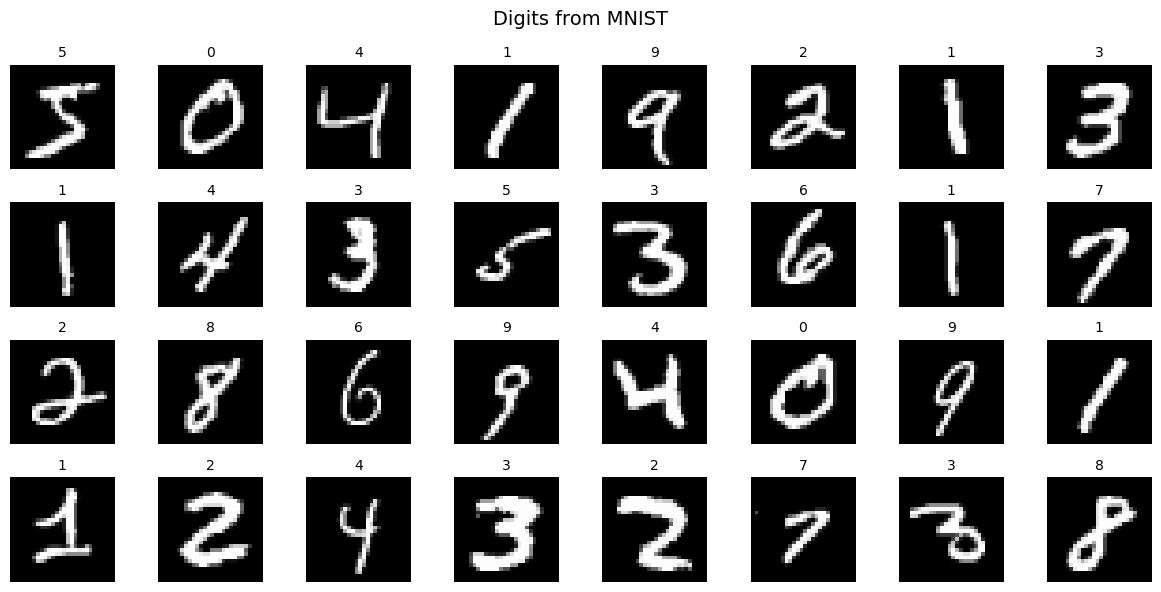

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(str(y_train[i]), fontsize=10)
    ax.axis('off')

plt.suptitle("Digits from MNIST", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
X_test = mnist_test.data.float() / 255.0
X_test.shape

torch.Size([10000, 28, 28])

We flatten the images because the model expects *vectors*, not matrices.
Each 28×28 2D image is converted into a flat vector of 784 numbers, and the -1 tells PyTorch: “calculate this dimension automatically.”

In [17]:
train_x = X_train.view(-1, 28*28)
train_y = tensor(y_train)

In [18]:
train_x.shape, train_y.shape

(torch.Size([60000, 784]), torch.Size([60000]))

With **zip()**, we pair each feature with its corresponding target into tuples (x, y). With **list()**, we materialize that pairing into an actual list so it can be indexed and reused.

In [19]:
dset = list(zip(train_x,train_y))
x,y = dset[0]
x.shape,y

(torch.Size([784]), tensor(5))

In [22]:
valid_x = X_test.view(-1, 28*28)
valid_y = tensor(y_test)
valid_dset = list(zip(valid_x, valid_y))

We create a function to randomly initialize the weights and we call .requires_grad_()
> `requires_grad=True` tells PyTorch to track all operations performed on that tensor to build a computational graph. This is what later allows, when calling .backward(), the gradients with respect to that tensor to be automatically computed via **backpropagation**. The resulting gradients are stored in the `.grad` attribute.

For example, if we have:
```
z = (w · x) + 1
```
and we want to know how much changes `z` if we change a little bit `w`, that's the derivative of `z` with respect to `w` --> **dz/dw**. 
This is the **gradient**.

**What is “the graph”?**
When you perform operations on a tensor with `requires_grad=True`, PyTorch builds a mental diagram like this:
```
pythonw = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)

y = w * x        # operation 1: multiplication
z = y + 1        # operation 2: addition
```

The “graph” that PyTorch constructs internally looks like this:

```
   w ──┐
       ├──► [×] ──► y ──┐
   x ──┘                ├──► [+] ──► z
                  1 ────┘
```

**What does “traversing the graph backward” mean?**
When you call `z.backward()`, PyTorch traces the path in reverse, from `z` to `w`, calculating derivatives at each step:

```
z ──► y ──► w
   ↑     ↑
 step 1  step 2
```
 
1. Step 1: How much does z change if y changes?
```
z = y + 1, so dz/dy = 1
```

2. Step 2: How much does y change if w changes?
```
y = w * x, and since x = 3, so dy/dw = 3
```

**Chain rule**: to find out how much z changes if w changes, multiply the derivatives along the path:
```
dz/dw = (dz/dy) × (dy/dw) = 1 × 3 = 3
```
And that result, 3, is stored in `w.grad`:
```
pythonw.grad   # tensor(3.)
```

In [32]:
def init_params(size, std=1.0): return (torch.randn(size)*std).requires_grad_()

As we have 10 labels (digits 0–9), we need a weight vector for each class. We stack them into a single matrix of shape (784, 10): 784 rows (one per input pixel) and 10 columns (one per class)."

In [33]:
weights = init_params((28*28, 10))

In [34]:
bias = init_params(10)

**linear1 — the model**

This is a linear model of the form `y = x·w + b`, generalized to matrices to process many images at once.

* `xb` is a batch of flattened images, of shape `(N, 784)`.
* `weights` is a matrix `(784, 10)`: one column of weights for each of the 10 digits.
* `bias` is a vector `(10,)`: one bias per class.
* `xb @ weights + bias` produces a matrix `(N, 10)` where each row contains the 10 scores (logits) for an image.

The highest score in each row indicates the predicted class. During training, we will adjust weights and bias so that these scores correctly reflect the true class.

**linear_model — the official PyTorch model**
Same thing as linear1, but it also initializes the parameters.

In [53]:
def linear1(xb): return xb@weights + bias
linear_model = nn.Linear(28*28, 10)

**DataLoader** is a PyTorch class (torch.utils.data.DataLoader) that wraps a dataset and handles serving it in mini-batches during training. Instead of processing all 60,000 images at once, it feeds them to the model in batches of 256. We use `shuffle=True` so each epoch sees the data in a different order.

`first()` is from fast.ai and gets the first batch from the DataLoader.

In [36]:
dl = DataLoader(dset, batch_size=256, shuffle=True)
xb,yb = first(dl)
xb.shape,yb.shape

(torch.Size([256, 784]), torch.Size([256]))

**DataLoader** but for the validation data set (test).

In [37]:
valid_dl = DataLoader(valid_dset, batch_size=256)

**calc_grad**
This function executes the three stages that occur in each batch:

1. **Forward** — `preds = model(xb)`
The model (linear1) computes `xb @ weights + bias`, producing 10 logits per image, in a `(256, 10)` shape.
2. **Loss** — `loss = F.cross_entropy(preds, yb)`
Measures the model’s error as a single number. Internally: applies _softmax_ to the logits to convert them into probabilities, and then calculates -`log(probability of the correct class)`. Heavily penalizes confident but incorrect predictions.
3. **Backward** — `loss.backward()`
Traverses the computational graph backward using backpropagation, and stores the gradients in `weights.grad` and `bias.grad`. These indicate how the weights should change to reduce the loss.

This function doesn't update the weights. It only fills the `.grad`. The update occurs later with the optimizer.

In [47]:
def calc_grad(xb, yb, model):
    preds = model(xb)
    loss = F.cross_entropy(preds, yb)
    loss.backward()

**batch_accuracy — human performance metric**
Returns the batch's accuracy, a number between 0 and 1.

* `xb.argmax(dim=1)` → index of the highest logit in each row = predicted class. Shape `(256, 10)` → `(256,)`.
```
xb (logits) = [[-1.66, -8.55, 14.85, ..., 5.22],     ← img 0: max in position 2
               [-3.99, -13.6,  4.70, ..., -6.46],    ← img 1: max in position 2
               [-11.7,  4.70, -11.6, ..., -6.46],    ← img 2: max in position 1
               ...
              ]                          form (256, 10)

preds = [2, 2, 1, ...]                   form (256,)
```
* `(preds == yb)` → Boolean tensor: True where correct, False where incorrect.
```
preds = [2, 2, 1, 7, 4, ...]
yb    = [2, 3, 1, 7, 9, ...]   ← true labels

(preds == yb) = [True, False, True, True, False, ...]
```
* `.float()` → converts True to 1.0, False to 0.0.
```
[True, False, True, True, False, ...]
            ↓ .float()
[1.0, 0.0, 1.0, 1.0, 0.0, ...]
```
* `.mean()` → the average of 1s and 0s is exactly the hit rate.
```
If there are 230 ones and 26 zeros in 256 elements:
mean = 230 / 256 = 0.898 → 89.8% accuracy
```

Example: 0.92 means that 92% of the images in the batch were correctly predicted.

In [48]:
def batch_accuracy(xb, yb):
    preds = xb.argmax(dim=1)
    return (preds == yb).float().mean()

**validate_epoch — the “test” at the end of each epoch**
Measures how well the model classifies the validation set.

* **List comprehension** → iterates through all batches in `valid_dl`, computes `model(xb)`, and measures the accuracy of each batch using `batch_accuracy`. Result: a list of scalars, one per batch.
* `torch.stack(accs)` → converts that Python list into a single tensor `(n_batches,)` so we can operate on it.
```
accs (list of 40 scalars) ──stack──► tensor of shape (40,)
[tensor(0.91), tensor(0.93), ...]  →  tensor([0.91, 0.93, 0.89, ..., 0.92])
```
* `.mean()` → averages the accuracies of all batches.
```
tensor([0.91, 0.93, 0.89, ..., 0.92]).mean()  →  tensor(0.9175)
```
* `.item()` → converts the scalar tensor to a Python float.
```
tensor(0.9175)  →  0.9175
```
* `round(..., 4)` → rounds to 4 decimal places for readability (e.g., 0.9175).
```
0.9175123456  →  0.9175
```

In [49]:
def validate_epoch(model):
    with torch.no_grad():
        accs = [batch_accuracy(model(xb), yb) for xb, yb in valid_dl]
    return round(torch.stack(accs).mean().item(), 4)

`.parameters()` -> Returns the existing parameters

In [55]:
w,b = linear_model.parameters()
w.shape, b.shape

(torch.Size([10, 784]), torch.Size([10]))

**BasicOptim — a homemade optimizer**
This is a manual version of `torch.optim.SGD` designed to demonstrate how an optimizer works internally.

* `__init__`: stores references to the model parameters and the learning rate.
* `step()`: applies the gradient descent rule — `param -= lr * grad` — to each parameter. Uses `.data` to bypass the computational graph (equivalent to `torch.no_grad()`).
* `zero_grad()`: sets `grad = None` so that the next `backward()` starts from scratch and gradients don't accumulate.

Equivalent to:
```
pythonopt = torch.optim.SGD(linear_model.parameters(), lr)
```

In [61]:
class BasicOptim:
    def __init__(self, params, lr): self.params, self.lr = list(params), lr

    def step(self, *args, **kwargs):
        for p in self.params: p.data -= p.grad.data * self.lr

    def zero_grad(self, *args, **kwargs):
        for p in self.params: p.grad = None

In [62]:
opt = BasicOptim(linear_model.parameters(), lr)

**train_epoch(model) — the complete cycle of an epoch**
For each batch from the DataLoader:

* `calc_grad(xb, yb, model)` → forward + loss + backward (fills the `.grad`)
* `opt.step()` → updates weights and biases with the gradients
* `opt.zero_grad()` → clears the gradients for the next batch

In [63]:
def train_epoch(model):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        opt.step()
        opt.zero_grad()

**train_model(model, epochs) — the complete cycle for all epochs**
We calculate each epoch and then print the result.

In [67]:
def train_model(model, epochs):
    for i in range(epochs):
        train_epoch(model)
        print(validate_epoch(model), end=' ')

In [66]:
train_model(linear_model, 10)

0.9129 0.9146 0.9168 0.9175 0.9075 0.9125 0.92 0.9208 0.9161 0.9189 

Same thing as what we did before, but simplified by using libraries.

In [111]:
linear_model = nn.Linear(28*28,10)
opt = SGD(linear_model.parameters(), lr)
train_model(linear_model, 10)

0.9028 0.9093 0.9128 0.9134 0.9146 0.9147 0.9153 0.9154 0.9155 0.9161 

Same thing as what we did before, but simplified by using Learner.

In [68]:
dls = DataLoaders(dl, valid_dl)

In [69]:
learn = Learner(dls, nn.Linear(28*28,10), opt_func=SGD,
                loss_func=F.cross_entropy, metrics=batch_accuracy)

In [70]:
learn.fit(10, lr=lr)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.336513,0.329819,0.905400,00:03
1,0.307550,0.300117,0.916000,00:03
2,0.294237,0.290221,0.919800,00:03
3,0.294970,0.283555,0.919100,00:03
4,0.293444,0.289654,0.916700,00:03
5,0.284273,0.291220,0.915100,00:04
6,0.278513,0.279194,0.922500,00:04
7,0.273462,0.279229,0.919800,00:04
8,0.274130,0.289795,0.917600,00:03
9,0.267523,0.282415,0.918600,00:03


**Testing the trained model — inference on an image**
This cell makes a prediction on an image from the validation set and displays it along with the model's output.

1. Selecting the image
* `x = valid_x[idx`] → a vector of 784 values (the flattened image).
* `y = valid_y[idx].item()` → the true label, as an integer.

2. Forward pass without gradients
* `with torch.no_grad()`: — disables graph tracking, since we are not training.
* `logits = learn.model(x)` — the 10 raw scores produced by the model.
* `probs = F.softmax(logits, dim=0)` — converts the logits into probabilities that sum to 1.
* `pred = logits.argmax().item()` — the index (class) with the highest score = prediction.

3. Visualize the result
* `x.view(28, 28)` reconstructs the 2D image from the flattened vector.

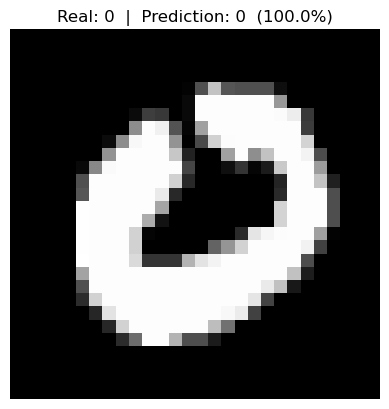

In [74]:
idx = 25   # change this number to try different images
x = valid_x[idx]
y = valid_y[idx].item()

with torch.no_grad():
    logits = learn.model(x)
    probs  = F.softmax(logits, dim=0)
    pred   = logits.argmax().item()

plt.imshow(x.view(28, 28), cmap='gray')
plt.title(f"Real: {y}  |  Prediction: {pred}  ({probs[pred]*100:.1f}%)")
plt.axis('off')
plt.show()